# Generating a type split matrix from stock-per-type data

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pathlib
from datetime import datetime

In [2]:
type_data = pd.read_excel("type_split_data_1981_2006.xlsx", skiprows = 2)

Test

In [3]:
print(type_data)

                                           Unnamed: 0          1981  \
0                     Stuehuse til landbrugsejendomme  1.561750e+05   
1                                          Parcelhuse  8.627730e+05   
2                        Række-, kæde- og dobbelthuse  1.572100e+05   
3                                        Etageboliger  8.209910e+05   
4                                                 Sum  1.997149e+06   
5                                      Stuehuse ratio  7.819897e-02   
6                                    Parcelhuse ratio  4.320023e-01   
7                                      Rekkehus ratio  7.871721e-02   
8                                  Etageboliger ratio  4.110815e-01   
9                                  Avg ratio stuehuse  6.247550e-02   
10                               Avg ratio parcelhuse  4.231135e-01   
11                                 Avg ratio rekkehus  1.180194e-01   
12                             Avg ratio etageboliger  3.963916e-01   
13    

In [4]:
# Get row 5 from column B-AA
ratio_stuehus = type_data.iloc[5, 1:27]
ratio_parcelhus = type_data.iloc[6, 1:27]
ratio_rekkehus = type_data.iloc[7, 1:27]
ratio_etage = type_data.iloc[8, 1:27]

print(ratio_etage)




1981    0.411081
1982    0.409713
1983    0.409677
1984    0.407506
1985    0.403746
1986    0.400859
1987    0.397217
1988    0.395562
1989     0.39405
1990       0.393
1991    0.392266
1992    0.392914
1993    0.392275
1994    0.392773
1995    0.393197
1996     0.39405
1997    0.394398
1998    0.393915
1999    0.393389
2000    0.392789
2001    0.392603
2002    0.392512
2003    0.392014
2004    0.390963
2005    0.392155
2006    0.391559
Name: 8, dtype: object


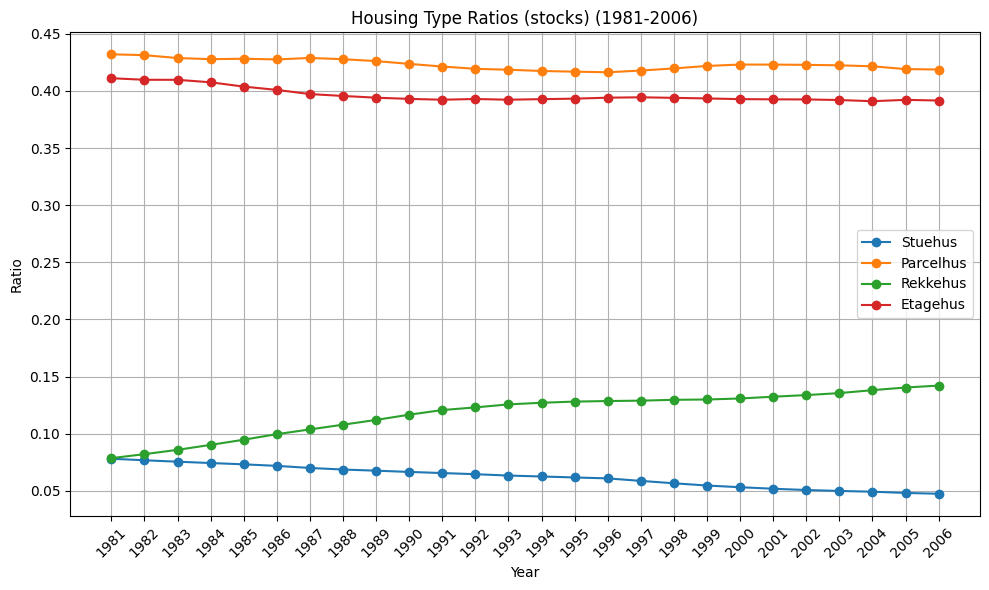

In [5]:
#Plot every ratio on the same graph
plt.figure(figsize=(10, 6))
plt.plot(ratio_stuehus.index, ratio_stuehus.values, label='Stuehus', marker='o')
plt.plot(ratio_parcelhus.index, ratio_parcelhus.values, label='Parcelhus', marker='o')
plt.plot(ratio_rekkehus.index, ratio_rekkehus.values, label='Rekkehus', marker='o')
plt.plot(ratio_etage.index, ratio_etage.values, label='Etagehus', marker='o')
plt.title('Housing Type Ratios (stocks) (1981-2006)')
plt.xlabel('Year')
plt.ylabel('Ratio')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [6]:
avg_ratio_stuehus = ratio_stuehus.mean()
avg_ratio_parcelhus = ratio_parcelhus.mean()
avg_ratio_rekkehus = ratio_rekkehus.mean()
avg_ratio_etage = ratio_etage.mean()


In [7]:
print(avg_ratio_stuehus.round(2))
print(avg_ratio_parcelhus.round(2))
print(avg_ratio_rekkehus.round(2))
print(avg_ratio_etage.round(2))


0.06
0.42
0.12
0.4


In [8]:
type_split_matrix_df = pd.DataFrame([{
    'Stuehus': avg_ratio_stuehus.round(2),
    'Parcelhus': avg_ratio_parcelhus.round(2),
    'Rekkehus': avg_ratio_rekkehus.round(2),
    'Etagehus': avg_ratio_etage.round(2)
}])

print(type_split_matrix_df)

   Stuehus  Parcelhus  Rekkehus  Etagehus
0     0.06       0.42      0.12       0.4


In [9]:
type_split_matrix_array = type_split_matrix_df.to_numpy()

print(type_split_matrix_array)

[[0.06 0.42 0.12 0.4 ]]


# Creating type-split matrix from inflow-data (MOST IMPORTANT)

In [10]:
inflow_type_data = pd.read_excel('inflows_ny_dwelling_98_25.xlsx', skiprows=2)

In [11]:
print(inflow_type_data)

                                           Unnamed: 0       Unnamed: 1  \
0                                           Nybyggeri  Boliger (antal)   
1                                                 NaN              NaN   
2                                                 NaN              NaN   
3                                                 NaN              NaN   
4                                                 NaN              NaN   
5                                                 NaN              NaN   
6                                                 NaN              NaN   
7                                                 NaN              NaN   
8                                                 NaN              NaN   
9                                                 NaN              NaN   
10                                                NaN              NaN   
11                                                NaN              NaN   
12                                    

In [13]:
ratio_stuehus_inflows = inflow_type_data.iloc[5, 2:27]
ratio_parcelhus_inflows = inflow_type_data.iloc[6, 2:27]
ratio_rekkehus_inflows = inflow_type_data.iloc[7, 2:27]
ratio_etage_inflows = inflow_type_data.iloc[8, 2:27]

print(ratio_etage_inflows)

Unnamed: 2    Ratio Etage
1998             0.299153
1999             0.193791
2000             0.258195
2001             0.273971
2002             0.338085
2003             0.422968
2004             0.519864
2005             0.536797
2006             0.574644
2007             0.739127
2008             0.452203
2009             0.339822
2010             0.166944
2011             0.187785
2012             0.365873
2013             0.367176
2014             0.339533
2015             0.278964
2016              0.50445
2017             0.724654
2018             0.887908
2019             1.159201
2020             1.361604
2021             1.121572
Name: 8, dtype: object
